# Values per hour

Onze *smart device* heeft drie verschillende "states".

1. Geen beweging getecteerd (dus geen fietsers).
2. Wel beweging gedetecteerd, maar geen lamp.
3. Wel beweging gedetecteerd en wel lamp.

Deze "states" worden continu opgeslagen in een Adafruit IO feed.

Door middel van het maken van API calls naar de Adafruit IO feed per uur, kan men een analyse maken over hoe vaak bepaalde "states" voorkomen.

Zo zou men bijvoorbeeld kunnen zien hoe vaak per uur er een fiets zonder licht aankomt.

## Stap 1

Uit de Adafruit IO API worden er 24 dataframes opgehaald; 1 voor elk uur in de dag.

Deze worden opgeslagen in een dictionary (`df_list`)

Vervolgens verifieer ik nog dat er inderdaad 24 dataframes zijn opgehaald.

In [8]:
import numpy as np
import pandas as pd

df_list = {}

date = "2021-01-14"

for hour in range (0, 24):
    df_list[x] = pd.read_json(f"https://io.adafruit.com/api/v2/avinash_student_account/feeds/bike-light-detector.sensor-states/data?start_time={date}T{x}:00:00Z&end_time={date}T{x+1}:00:00Z")

len(df_list)

24

## Stap 2

Als voorbeeld wordt een dataframe getoond; in dit geval van 14:00.

In [9]:
df_list[14]

,id,value,feed_id,feed_key,created_at,created_epoch,expiration
0,0EMR6AN0QF6BJ4E3SM0VWDXFSA,1,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:46+00:00,1610633986,2021-03-15T13:19:46Z
1,0EMR6AM4AZHYZ2BDENVAZTPEQY,1,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:43+00:00,1610633983,2021-03-15T13:19:43Z
2,0EMR6AK7X6CK3D7GMH052D3GGZ,1,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:40+00:00,1610633980,2021-03-15T13:19:40Z
3,0EMR6AJBG0BAA7S7MD23BFNXSB,1,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:37+00:00,1610633977,2021-03-15T13:19:37Z
4,0EMR6AHF11GTK3VAK51NXRY8G6,1,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:34+00:00,1610633974,2021-03-15T13:19:34Z
...,...,...,...,...,...,...,...
106,0EMR609T0TBVMVDQ5D461C22Z5,2,1532824,bike-light-detector.sensor-states,2021-01-14 14:01:40+00:00,1610632900,2021-03-15T13:01:40Z
107,0EMR602ZTHFBFPW7S85MTKW89P,2,1532824,bike-light-detector.sensor-states,2021-01-14 14:01:18+00:00,1610632878,2021-03-15T13:01:18Z
108,0EMR5ZW63EZWYAPFYQ2J3HQMJX,2,1532824,bike-light-detector.sensor-states,2021-01-14 14:00:56+00:00,1610632856,2021-03-15T13:00:56Z
109,0EMR5ZNCKWDDADGXGPVMYN1NV1,2,1532824,bike-light-detector.sensor-states,2021-01-14 14:00:33+00:00,1610632833,2021-03-15T13:00:33Z


## Stap 3

Door middel van de lijst van dataframes, wordt er een lijst gemaakt met *Series* van hoe vaak iedere waarde voorkomt.

Dit gaat op dezelfde manier als bij de staafdiagram; echter wordt het hier uitgevoerd per uur.

Ook moet er gecheckt worden of de dataframe niet leeg is; anders werkt het niet.

In [10]:
count_list = {}

for key in df_list:
    if not df_list[key].empty:
        count_list[key] = df_list[key]["value"].value_counts()

## Stap 4

Deze lijst van series wordt omgezet naar een dataframe.
Vervolgens worden de rijen kolommen omgewisseld.

De reden hiervoor is om de X en Y assen op de lijndiagram goed te tonen.

In [11]:
count_list_frame = pd.DataFrame(count_list).transpose()

count_list_frame

,1,2,3
13,105.0,87.0,9.0
14,80.0,24.0,7.0
15,103.0,6.0,NaN


## Stap 5

De namen van de kolommen worden aangepast, om meer duidelijkheid te geven wat iedere kolom betekent.

In [12]:
count_list_frame = count_list_frame.rename(columns={1: "Geen beweging", 2: "Wel beweging, geen licht", 3: "Beweging en licht"})

count_list_frame

,Geen beweging,"Wel beweging, geen licht",Beweging en licht
13,105.0,87.0,9.0
14,80.0,24.0,7.0
15,103.0,6.0,NaN


## Stap 6

De dataframe wordt omgezet tot een lijndiagram.

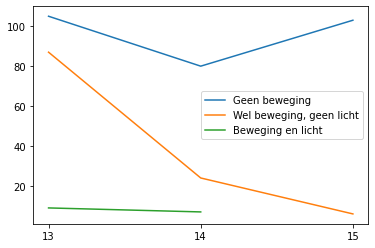

In [13]:
ax = count_list_frame.plot()
ax.set_xticks(count_list_frame.index)

